In [1]:
from google.colab import drive

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
import shap
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mannwhitneyu
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
import matplotlib
from IPython.display import display

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train:(3500, 26),Val:(750, 26),Test:(750, 26)

 Applying SMOTE to balance training data
Before SMOTE:Positive ratio=0.0506
Encoding column:scholarship_received
After SMOTE:Positive ratio=0.5000
Balanced training set size:(6646, 18)

 Model trained successfully.

 Threshold candidates based on validation data:
youden_optimal      →0.11
f1_optimal          →0.403
recall_focus        →0.15
precision_focus     →0.4

 Final decision threshold=0.403


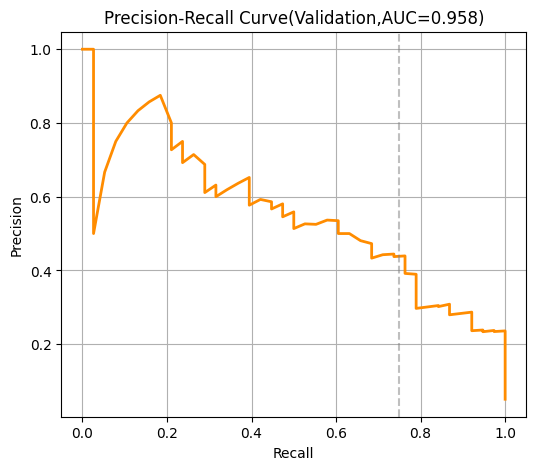

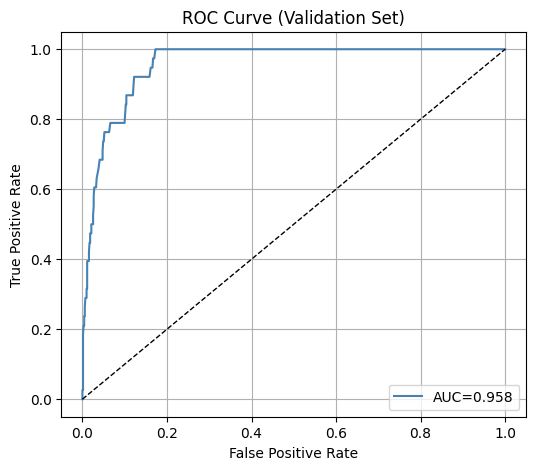


 [Scenario A–High Recall(T=0.15)] Threshold=0.15
              precision    recall  f1-score   support

           0     0.9917    0.8413    0.9103       712
           1     0.2260    0.8684    0.3587        38

    accuracy                         0.8427       750
   macro avg     0.6089    0.8549    0.6345       750
weighted avg     0.9529    0.8427    0.8824       750

ROC-AUC Score:0.9350


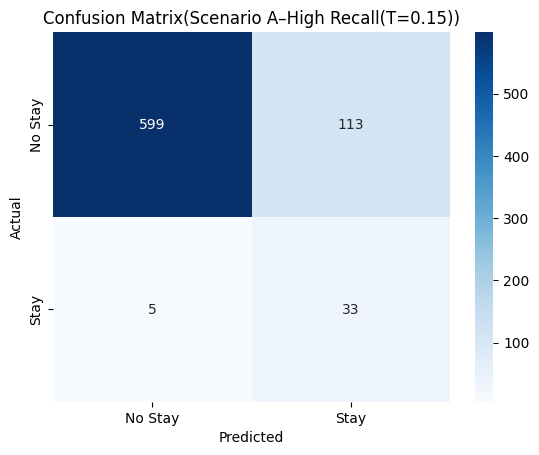

False Positive Rate:15.87%
------------------------------------------------------------

 [Scenario B–Balanced(F1 Best)] Threshold=0.403
              precision    recall  f1-score   support

           0     0.9717    0.9649    0.9683       712
           1     0.4186    0.4737    0.4444        38

    accuracy                         0.9400       750
   macro avg     0.6952    0.7193    0.7064       750
weighted avg     0.9437    0.9400    0.9417       750

ROC-AUC Score:0.9350


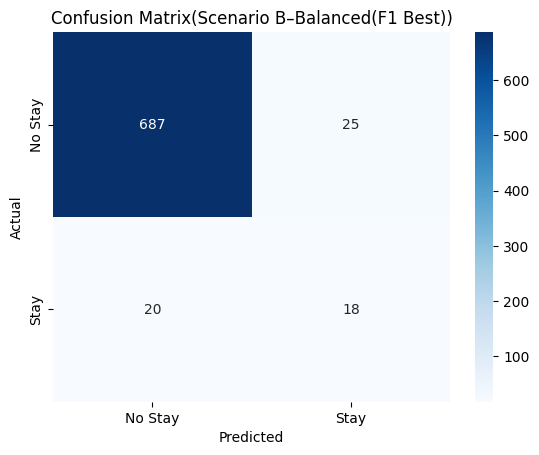

False Positive Rate:3.51%
------------------------------------------------------------

 [Scenario C–High Precision (T=0.40)] Threshold=0.4
              precision    recall  f1-score   support

           0     0.9731    0.9649    0.9690       712
           1     0.4318    0.5000    0.4634        38

    accuracy                         0.9413       750
   macro avg     0.7025    0.7324    0.7162       750
weighted avg     0.9457    0.9413    0.9434       750

ROC-AUC Score:0.9350


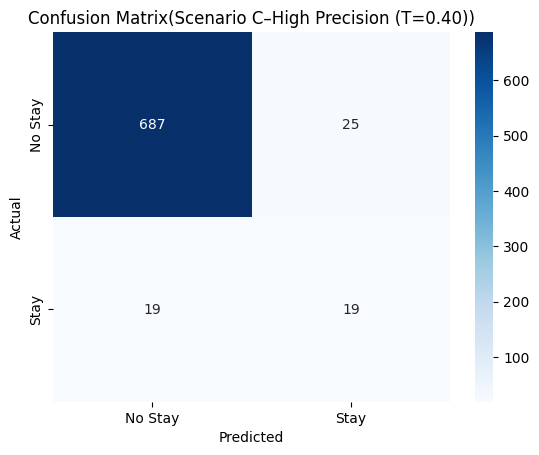

False Positive Rate:3.51%
------------------------------------------------------------


/tmp/ipython-input-2886110344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance.head(10),x="importance",y="feature",palette="viridis")


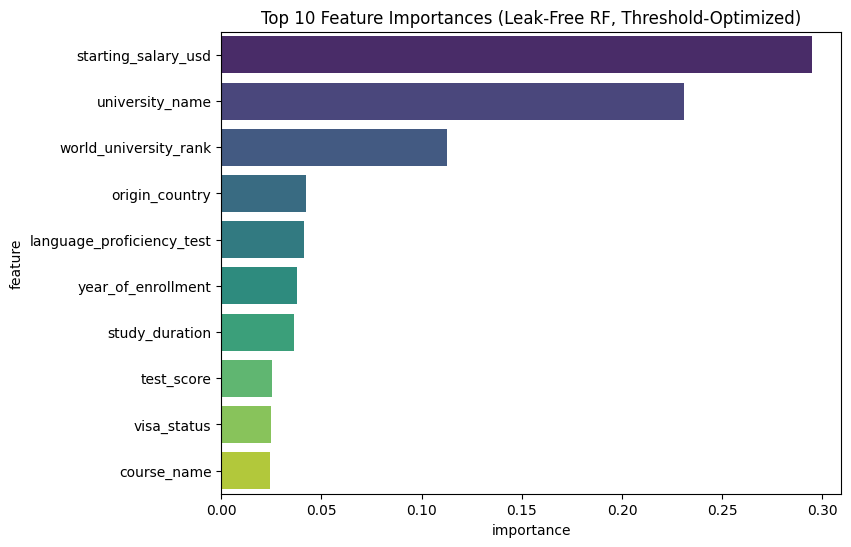


 Full training,tuning and evaluation complete.


In [4]:
%run /content/drive/MyDrive/StayInCanada_Project/INT4096_Model_training_and_evaluation.ipynb

In [5]:
data=pd.concat([pd.read_csv(f'/content/drive/MyDrive/StayInCanada_Project/train_preprocessed.csv'),
        pd.read_csv(f'/content/drive/MyDrive/StayInCanada_Project/val_preprocessed.csv'),
        pd.read_csv(f'/content/drive/MyDrive/StayInCanada_Project/test_preprocessed.csv')],ignore_index=True)

In [6]:
print("Data successfully loaded:",data.shape)
display(data.head())

Data successfully loaded: (5000, 26)


,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,...,visa_status,post_graduation_visa,language_proficiency_test,test_score,world_university_rank,study_duration,stem_flag,placed_flag,scholarship_flag,stay_in_canada
0,S01145,2,1,21,61,3,2,2019.0,No,4,...,1,3,0,0.998069,0.966854,2.0,1,1,0,0
1,S01007,2,0,27,72,7,1,2023.0,No,4,...,2,0,2,0.930810,1.611446,2.0,0,1,0,1
2,S01758,4,7,1,20,10,6,2019.0,Yes,3,...,5,1,0,0.359101,-0.285495,3.0,0,1,1,0
3,S02238,1,8,38,66,9,0,2022.0,Yes,4,...,1,1,2,0.998069,-0.856419,1.0,0,1,1,0
4,S00018,4,8,27,21,0,3,2023.0,Yes,2,...,4,4,2,0.729030,-0.359163,2.0,1,0,1,0


In [7]:
print("\n (1/5)Geographic Distribution of International Students")


 (1/5)Geographic Distribution of International Students


In [8]:
country_code_map = {
    0:"CAN",# Canada
    1:"FIN", # Finland
    2:"DEU",# Germany
    3:"IND", # India
    4:"IRL",# Ireland
    5:"RUS",# Russia
    6:"ZAF", # South Africa
    7:"ARE",# UAE
    8:"GBR",# UK
    9:"USA"# USA
}
country_name_map={
    0:"Canada",
    1:"Finland",
    2:"Germany",
    3:"India",
    4:"Ireland",
    5:"Russia",
    6:"South Africa",
    7:"UAE",
    8:"UK",
    9:"USA"
}


In [10]:
geo_stats=data.groupby("origin_country").agg({"stay_in_canada":["count","sum","mean"]}).reset_index()
geo_stats.columns=["origin_country","total_students","stay_count","stay_rate"]

In [11]:
geo_stats["country_code"]=geo_stats["origin_country"].map(country_code_map)
geo_stats["country_name"]=geo_stats["origin_country"].map(country_name_map)
geo_stats["stay_rate_pct"]=geo_stats["stay_rate"]*100
geo_stats=geo_stats.sort_values("stay_rate",ascending=False)

In [12]:
print("\n"+"___"*80)
print("GEOGRAPHIC DISTRIBUTION ANALYSIS")
print("___"*80)
fig1 = px.choropleth(geo_stats,locations="country_code",color="stay_rate",hover_name="country_name",hover_data={
        "country_code":False,
        "total_students":True,
        "stay_count":True,
        "stay_rate":":.1%"},color_continuous_scale="YlGnBu",title="Global Student Stay-in-Canada Rate by Origin Country",labels={"stay_rate":"Stay Rate"})
fig1.update_layout(geo=dict(projection_type="natural earth",showland=True,landcolor="rgba(200,200,200,0.5)",showocean=True,oceancolor="rgba(100,150,200,0.3)",coastlinecolor="white",showcoastlines=True,showframe=True,framecolor="lightgray",framewidth=1),coloraxis_colorbar=dict(title="Stay Rate",tickformat=".1%",thickness=15,len=0.7),font=dict(size=12),title_font_size=14,title_x=0.5,height=600,width=1200)
fig1.show()


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
GEOGRAPHIC DISTRIBUTION ANALYSIS
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________


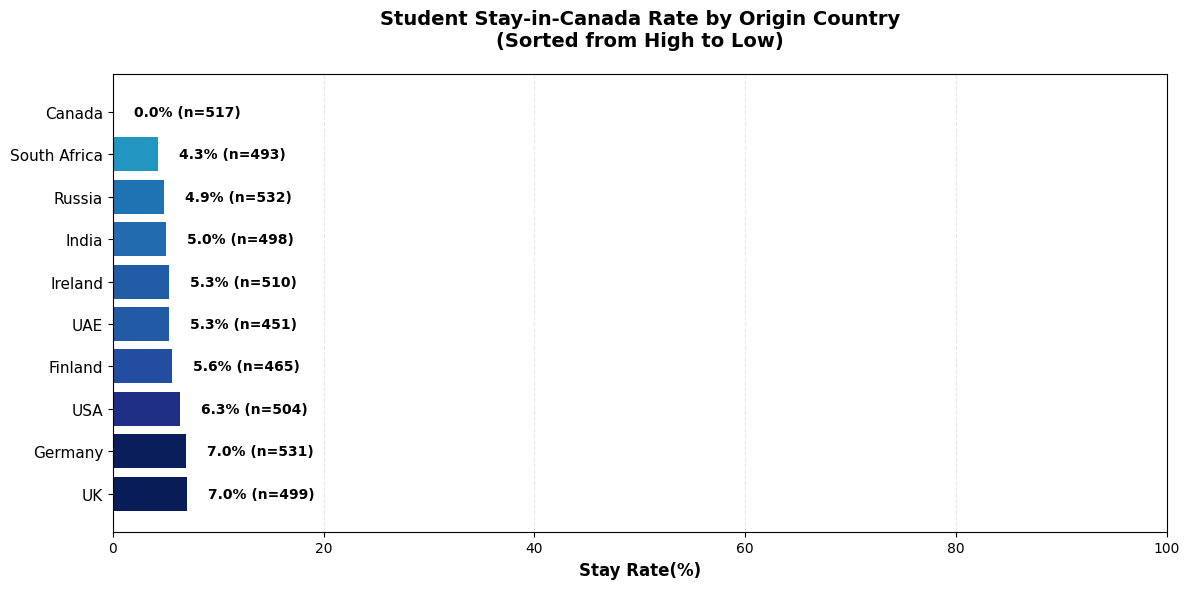

In [13]:
fig2,ax=plt.subplots(figsize=(12,6))
colors_list=plt.cm.YlGnBu(geo_stats['stay_rate'].values/geo_stats['stay_rate'].max())
bars=ax.barh(range(len(geo_stats)),geo_stats['stay_rate_pct'].values,color=colors_list)
ax.set_yticks(range(len(geo_stats)))
ax.set_yticklabels(geo_stats['country_name'].values,fontsize=11)
ax.set_xlabel("Stay Rate(%)",fontsize=12,fontweight='bold')
ax.set_title("Student Stay-in-Canada Rate by Origin Country\n(Sorted from High to Low)",fontsize=14,fontweight='bold',pad=20)
ax.set_xlim(0,100)
ax.grid(axis='x',alpha=0.3,linestyle='--')
for i,(idx,row) in enumerate(geo_stats.iterrows()):
    ax.text(row['stay_rate_pct']+2,i,f"{row['stay_rate_pct']:.1f}% (n={int(row['total_students'])})",va='center',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

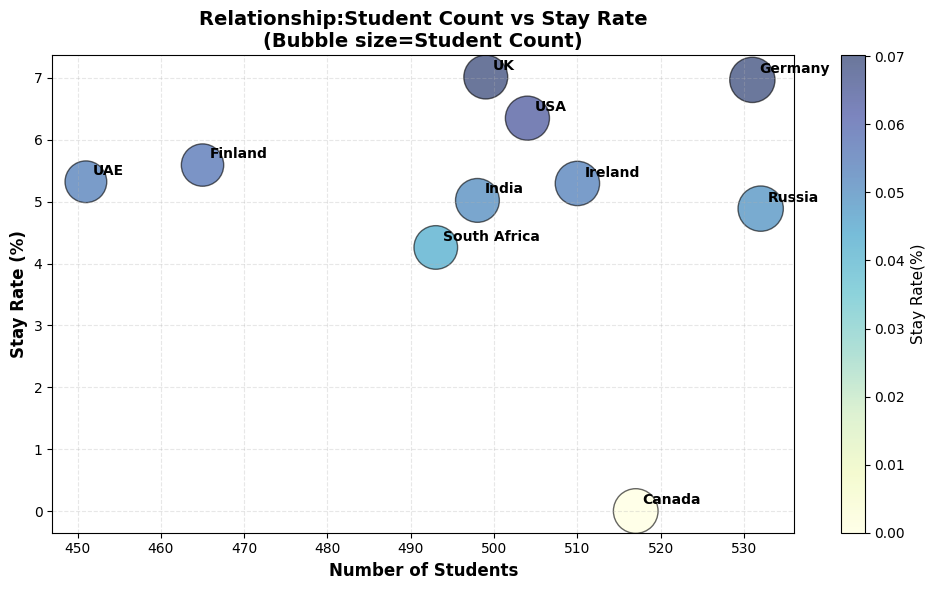

In [14]:
fig3,ax=plt.subplots(figsize=(10,6))
scatter=ax.scatter(geo_stats['total_students'],geo_stats['stay_rate_pct'],s=geo_stats['total_students']*2,alpha=0.6,
c=geo_stats['stay_rate'],cmap='YlGnBu',edgecolors='black',linewidth=1)
for idx,row in geo_stats.iterrows():
    ax.annotate(row['country_name'],(row['total_students'], row['stay_rate_pct']),
    xytext=(5,5),textcoords='offset points',fontsize=10,fontweight='bold')
ax.set_xlabel("Number of Students",fontsize=12,fontweight='bold')
ax.set_ylabel("Stay Rate (%)",fontsize=12,fontweight='bold')
ax.set_title("Relationship:Student Count vs Stay Rate\n(Bubble size=Student Count)",fontsize=14,fontweight='bold')
ax.grid(True,alpha=0.3,linestyle='--')
cbar=plt.colorbar(scatter,ax=ax)
cbar.set_label("Stay Rate(%)",fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
print("\n"+"___"*80)
print("SUMMARY STATISTICS")
print("___"*80)
print(f"Total Countries:{len(geo_stats)}")
print(f"Total Students:{geo_stats['total_students'].sum():,}")
print(f"Total Students Staying in Canada:{geo_stats['stay_count'].sum():,}")
print(f"Global Average Stay Rate:{geo_stats['stay_rate'].mean():.2%}")
print("\n\n" + "___" * 80)
print("DETAILED STATISTICS BY COUNTRY")
print("___"*80)
print(f"{'Country':<15}|{'Students':<8}|{'Stay Count':<10}|{'Stay Rate':<10}|{'Stay Rate %':<12}")
print("___"*80)
for idx, row in geo_stats.iterrows():
    print(f"{row['country_name']:<15}|{int(row['total_students']):<8}| "
          f"{int(row['stay_count']):<10}|{row['stay_rate']:<10.4f}|{row['stay_rate_pct']:<12.2f}%")
print("\n\n"+"___"*80)
print("KEY INSIGHTS AND FINDINGS")
print("___"*80)
max_rate=geo_stats.iloc[0]
print(f"Highest Stay Rate:{max_rate['country_name']}({max_rate['stay_rate_pct']:.1f}%)-{int(max_rate['stay_count'])}students stayed")
min_rate=geo_stats.iloc[-1]
print(f"Lowest Stay Rate:{min_rate['country_name']}({min_rate['stay_rate_pct']:.1f}%)-{int(min_rate['stay_count'])}students stayed")
max_students=geo_stats.loc[geo_stats['total_students'].idxmax()]
print(f"Largest Student Population:{max_students['country_name']}({int(max_students['total_students'])}students)- Stay Rate:{max_students['stay_rate_pct']:.1f}%")
max_stay=geo_stats.loc[geo_stats['stay_count'].idxmax()]
print(f"Most Students Staying:{max_stay['country_name']}({int(max_stay['stay_count'])}students stayed)")
high_rate=geo_stats[geo_stats['stay_rate']>0.4]
if len(high_rate)>0:
    print(f"High Stay Rate Countries (>40%):{','.join(high_rate['country_name'].values)}")
low_rate=geo_stats[geo_stats['stay_rate']<0.1]
if len(low_rate)>0:
    print(f"Low Stay Rate Countries(<10%):{','.join(low_rate['country_name'].values)}")
print("\n"+"___"*80)



________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
SUMMARY STATISTICS
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
Total Countries:10
Total Students:5,000
Total Students Staying in Canada:253
Global Average Stay Rate:5.07%


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
DETAILED STATISTICS BY COUNTRY
____________________________________________________________________________________________________________________

In [15]:
print("\n (2/5)Educational Background Analysis")


 (2/5)Educational Background Analysis


____________________________________________________________________________________________________________________________________________________________________________________
EDUCATIONAL BACKGROUND ANALYSIS
____________________________________________________________________________________________________________________________________________________________________________________

No Stay(0):
Median:-0.285
Mean:-0.032
Std Dev:0.966

Stayed in Canada(1):
 Median:-0.285
 Mean:0.593
Std Dev:1.371

Statistical Significance:
 Mann-Whitney U Statistic:490291.500
P-value:0.0000
Result is STATISTICALLY SIGNIFICANT (p<0.05)
____________________________________________________________________________________________________________________________________________________________________________________


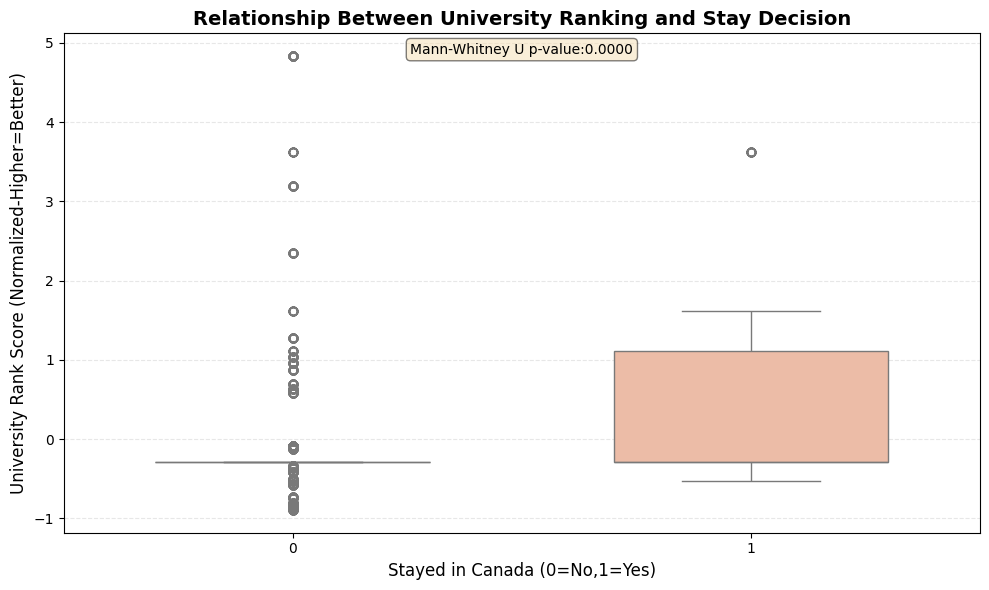

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x="stay_in_canada",y="world_university_rank",data=data,palette="coolwarm",width=0.6,hue="stay_in_canada",legend=False)
plt.title("Relationship Between University Ranking and Stay Decision",fontsize=14,fontweight='bold')
plt.xlabel("Stayed in Canada (0=No,1=Yes)",fontsize=12)
plt.ylabel("University Rank Score (Normalized-Higher=Better)",fontsize=12)
plt.grid(axis='y',alpha=0.3,linestyle='--')
group_0=data[data['stay_in_canada']==0]['world_university_rank'].dropna()
group_1=data[data['stay_in_canada']==1]['world_university_rank'].dropna()
statistic,pvalue=mannwhitneyu(group_0,group_1)
plt.text(0.5,plt.ylim()[1]*0.95,f'Mann-Whitney U p-value:{pvalue:.4f}',ha='center',fontsize=10,bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
print("___"*60)
print("EDUCATIONAL BACKGROUND ANALYSIS")
print("___" * 60)
print(f"\nNo Stay(0):")
print(f"Median:{group_0.median():.3f}")
print(f"Mean:{group_0.mean():.3f}")
print(f"Std Dev:{group_0.std():.3f}")
print(f"\nStayed in Canada(1):")
print(f" Median:{group_1.median():.3f}")
print(f" Mean:{group_1.mean():.3f}")
print(f"Std Dev:{group_1.std():.3f}")
print(f"\nStatistical Significance:")
print(f" Mann-Whitney U Statistic:{statistic:.3f}")
print(f"P-value:{pvalue:.4f}")
if pvalue <0.05:
    print(f"Result is STATISTICALLY SIGNIFICANT (p<0.05)")
else:
    print(f"Result is NOT statistically significant(p>=0.05)")
print("___"*60)
plt.tight_layout()
plt.show()

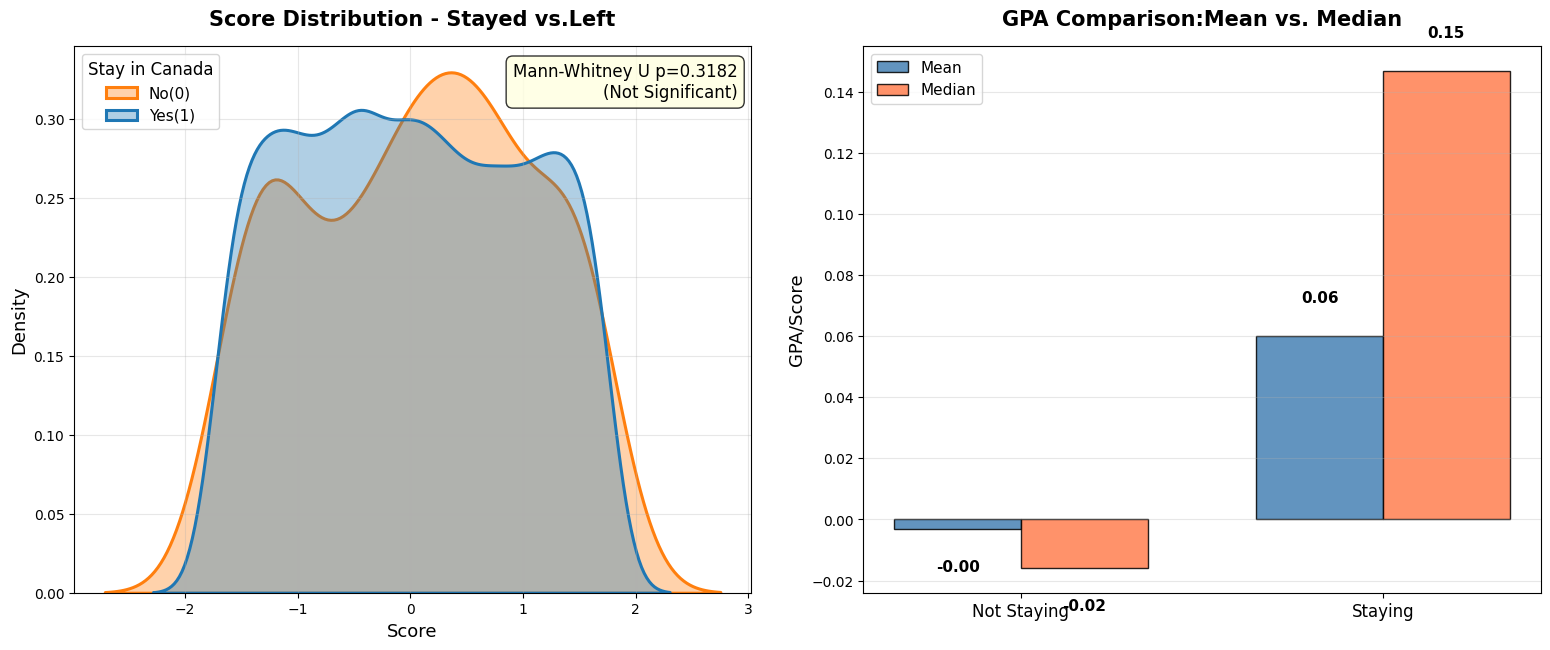


______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
（GPA）Score Distribution Analysis
______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
Students Who Did NOT Stay (stay_in_canada=0):
Median:-0.016
Mean:-0.003
Std Dev:1.000
Sample Size:4747

Students Who Stayed(stay_in_canada=1):
Median:0.147
Mean:0.060
Std Dev:1.010
Sample Size:253

Statistical Test (Mann-Whitney U):
Statistic:578164.50
P-value:0.318200
Result:Not Statistically Significant(p≥0.05)


In [18]:
stay_0=data[data['stay_in_canada']==0]['gpa_or_score'].dropna()
stay_1=data[data['stay_in_canada']==1]['gpa_or_score'].dropna()
stat_gpa,pvalue_gpa=mannwhitneyu(stay_0,stay_1)
fig,axes=plt.subplots(1,2,figsize=(16,7))
ax1,ax2=axes
sns.kdeplot(data=data,x="gpa_or_score",hue="stay_in_canada",fill=True,common_norm=False,alpha=0.35,linewidth=2.2,ax=ax1)
ax1.set_title("Score Distribution - Stayed vs.Left",fontsize=15,fontweight='bold',pad=15)
ax1.set_xlabel("Score",fontsize=13)
ax1.set_ylabel("Density",fontsize=13)
ax1.grid(alpha=0.3)
ax1.legend(title="Stay in Canada",labels=["No(0)","Yes(1)"],fontsize=11,title_fontsize=12,loc="upper left",frameon=True)
text_box_color='lightgreen' if pvalue_gpa <0.05 else 'lightyellow'
text_result="(Significant)" if pvalue_gpa <0.05 else "(Not Significant)"
ax1.text(0.98,0.97,f"Mann-Whitney U p={pvalue_gpa:.4f}\n{text_result}",transform=ax1.transAxes,ha='right',va='top',fontsize=12,bbox=dict(boxstyle='round,pad=0.4',facecolor=text_box_color,alpha=0.8))
gpa_comparison=pd.DataFrame({'Group':['Not Staying','Staying'],'Mean GPA':[stay_0.mean(),stay_1.mean()],'Median GPA':[stay_0.median(),stay_1.median()]})
x_pos=np.arange(len(gpa_comparison))
width=0.35
bars1=ax2.bar(x_pos - width/2,gpa_comparison['Mean GPA'],width,label='Mean',alpha=0.85,color='steelblue',edgecolor='black')
bars2=ax2.bar(x_pos+width/2,gpa_comparison['Median GPA'],width,label='Median',alpha=0.85,color='coral',edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(gpa_comparison['Group'],fontsize=12)
ax2.set_ylabel('GPA/Score',fontsize=13)
ax2.set_title('GPA Comparison:Mean vs. Median',fontsize=15,fontweight='bold',pad=15)
ax2.legend(fontsize=11,loc="upper left")
ax2.grid(axis='y',alpha=0.3)
for bar in bars1 + bars2:
    height=bar.get_height()
    if height>=0:
        va='bottom'
        offset=0.01
    else:
        va='top'
        offset=-0.01
    ax2.text(bar.get_x() + bar.get_width()/2,height +offset,f"{height:.2f}",ha='center',va=va,fontsize=11,fontweight='bold',color='black')
plt.tight_layout(pad=2.5)
plt.show()
print("\n"+"___"*90)
print("（GPA）Score Distribution Analysis")
print("___"*90)
print("Students Who Did NOT Stay (stay_in_canada=0):")
print(f"Median:{stay_0.median():.3f}")
print(f"Mean:{stay_0.mean():.3f}")
print(f"Std Dev:{stay_0.std():.3f}")
print(f"Sample Size:{len(stay_0)}")
print("\nStudents Who Stayed(stay_in_canada=1):")
print(f"Median:{stay_1.median():.3f}")
print(f"Mean:{stay_1.mean():.3f}")
print(f"Std Dev:{stay_1.std():.3f}")
print(f"Sample Size:{len(stay_1)}")
print("\nStatistical Test (Mann-Whitney U):")
print(f"Statistic:{stat_gpa:.2f}")
print(f"P-value:{pvalue_gpa:.6f}")
if pvalue_gpa<0.05:
    print("Result:Statistically Significant(p<0.05)")
else:
    print("Result:Not Statistically Significant(p≥0.05)")

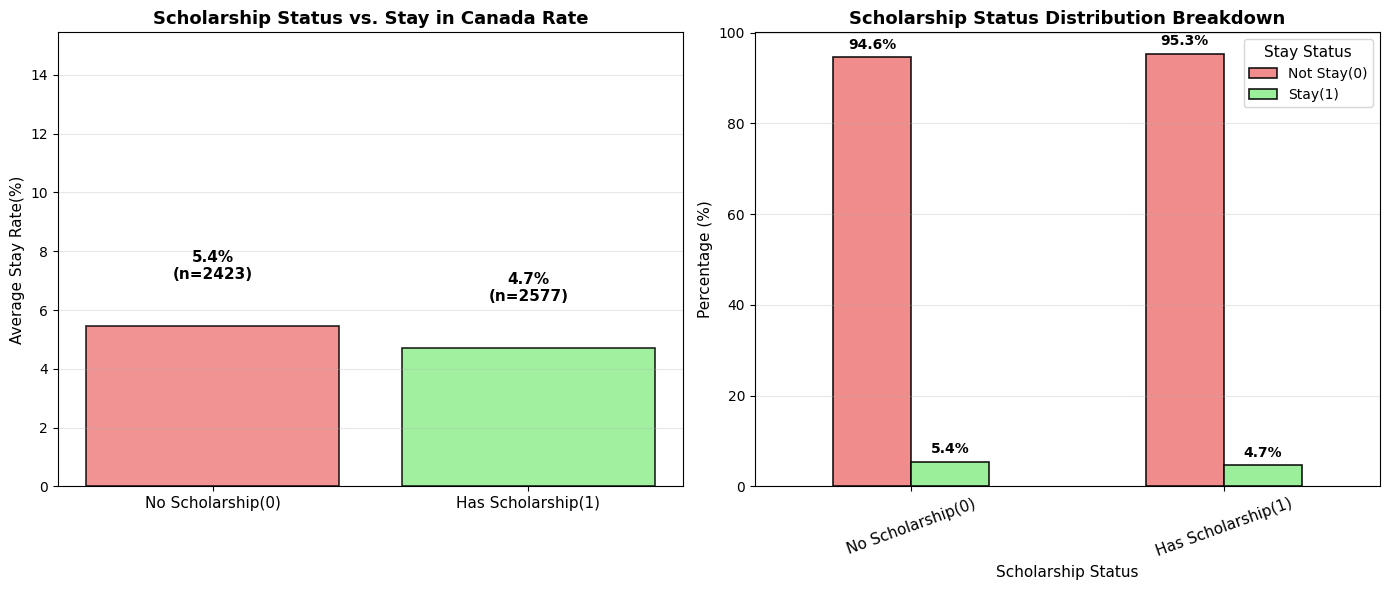


______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
Scholarship Status Analysis
______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

No Scholarship:
Total Students:2423
Students Staying in Canada:132
Stay Rate:0.0545(5.45%)

Has Scholarship:
Total Students:2577
Students Staying in Canada:121
Stay Rate:0.0470(4.70%)

Chi-Square Test (Independence Test):
Chi-Square Statistic:1.3192
P-value:0.250735
 Result:Not Statistically Significant(p≥0.05)
 Interpretation:Scholarship status is NOT significantly related to stay decisions.

_______________________________

In [19]:
scholar=data.groupby("scholarship_flag")["stay_in_canada"].agg(['count','sum','mean']).reset_index()
scholar.columns=['scholarship_flag','total_students','stay_count','stay_rate']
chi2,chi_pvalue,dof,expected=chi2_contingency(pd.crosstab(data['scholarship_flag'],data['stay_in_canada']))
fig,axes=plt.subplots(1,2,figsize=(14,6))
ax3,ax4=axes
colors=['#f08080','#90ee90']
bars=ax3.bar(range(len(scholar)),scholar['stay_rate'].values * 100,color=colors,alpha=0.85,edgecolor='black',linewidth=1.2)
ax3.set_xticks(range(len(scholar)))
ax3.set_xticklabels(['No Scholarship(0)','Has Scholarship(1)'],fontsize=11)
ax3.set_ylabel('Average Stay Rate(%)',fontsize=11)
ax3.set_title('Scholarship Status vs. Stay in Canada Rate',fontsize=13,fontweight='bold')
ax3.set_ylim(0,(max(scholar['stay_rate'])*100)+10)
ax3.grid(axis='y',alpha=0.3)
for i, (bar,rate) in enumerate(zip(bars,scholar['stay_rate'].values * 100)):
    height=bar.get_height()
    ax3.text(bar.get_x()+bar.get_width()/2.,height+1.5,f"{rate:.1f}%\n(n={int(scholar['total_students'].iloc[i])})",ha='center',va='bottom',fontsize=11,fontweight='bold')
scholar_detail=data.groupby(['scholarship_flag','stay_in_canada']).size().unstack(fill_value=0)
scholar_detail.index=['No Scholarship(0)','Has Scholarship(1)']
scholar_detail.columns=['Not Stay(0)','Stay(1)']
scholar_pct=scholar_detail.div(scholar_detail.sum(axis=1),axis=0) * 100
scholar_pct.plot(kind='bar',ax=ax4,color=['#f08080','#90ee90'],alpha=0.9,edgecolor='black',linewidth=1.2)
ax4.set_xlabel('Scholarship Status',fontsize=11)
ax4.set_ylabel('Percentage (%)',fontsize=11)
ax4.set_title('Scholarship Status Distribution Breakdown',fontsize=13,fontweight='bold')
ax4.set_xticklabels(scholar_pct.index,rotation=20,ha='center',fontsize=11)
ax4.legend(title='Stay Status', labels=['Not Stay(0)','Stay(1)'],fontsize=10,title_fontsize=11)
ax4.grid(axis='y',alpha=0.3)
for container in ax4.containers:
    ax4.bar_label(container,fmt='%.1f%%',fontsize=10,padding=4,weight='bold')
plt.tight_layout()
plt.show()
print("\n"+"___"*90)
print("Scholarship Status Analysis")
print("___"*90)
for idx, row in scholar.iterrows():
    label="Has Scholarship" if row['scholarship_flag']==1 else "No Scholarship"
    print(f"\n{label}:")
    print(f"Total Students:{int(row['total_students'])}")
    print(f"Students Staying in Canada:{int(row['stay_count'])}")
    print(f"Stay Rate:{row['stay_rate']:.4f}({row['stay_rate']*100:.2f}%)")
print("\nChi-Square Test (Independence Test):")
print(f"Chi-Square Statistic:{chi2:.4f}")
print(f"P-value:{chi_pvalue:.6f}")
if chi_pvalue<0.05:
    print("Result:Statistically Significant(p<0.05)")
    print("Interpretation:Scholarship status is significantly related to stay decisions.")
else:
    print(" Result:Not Statistically Significant(p≥0.05)")
    print(" Interpretation:Scholarship status is NOT significantly related to stay decisions.")
print("\n"+"___"*90)
print("key points")
print("___"*90)
mean_diff=stay_1.mean() - stay_0.mean()
print("\n1. GPA Impact:")
print(f"-Avg GPA for students who stayed is higher({stay_1.mean():.3f}vs{stay_0.mean():.3f})")
print(f"-Difference:{mean_diff:.3f}")
scholarship_impact=(
    (scholar.loc[scholar['scholarship_flag']==1,'stay_rate'].values[0] -
     scholar.loc[scholar['scholarship_flag']==0,'stay_rate'].values[0])*100)
print("\n2. Scholarship Impact:")
print(f"- With Scholarship:{scholar.loc[1,'stay_rate']*100:.2f}% stay rate")
print(f"- Without Scholarship:{scholar.loc[0,'stay_rate']*100:.2f}% stay rate")
print(f"- Difference:{scholarship_impact:.2f}percentage points")
if scholarship_impact >0:
    print("- Interpretation:Students with scholarships are more likely to stay in Canada.")
else:
    print("-Interpretation:Students with scholarships are less likely to stay in Canada.")
print("\n"+"___"*90)

In [20]:
print("\n (3/5) Field of Study and STEM Difference Analysis")



 (3/5) Field of Study and STEM Difference Analysis


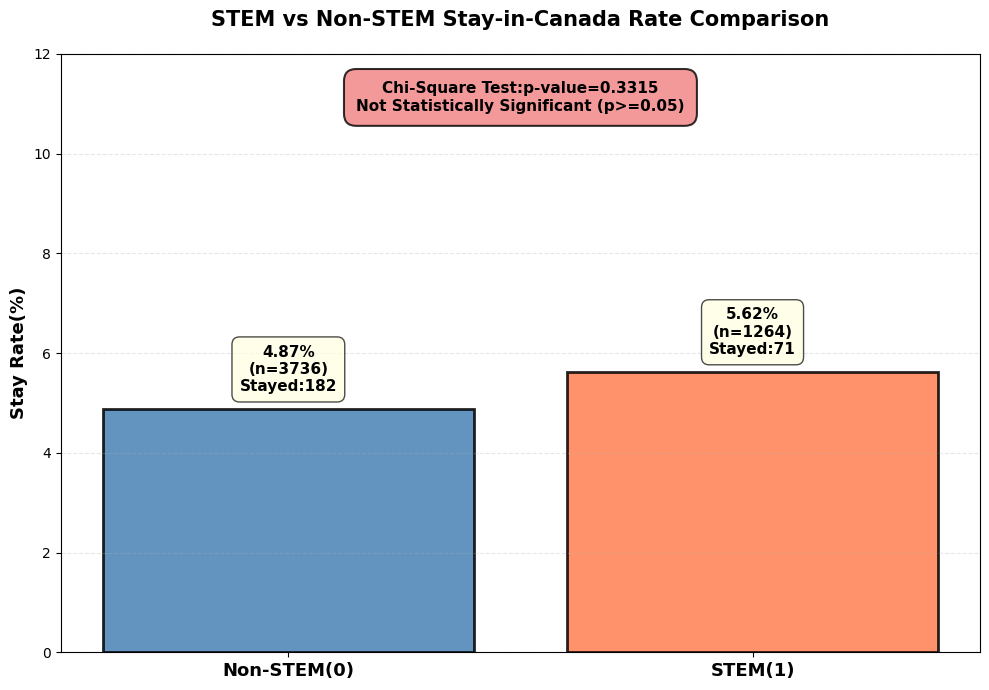


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

Non-STEMFields:
Total Students:3,736
Students Stayed:182
Stay Rate:4.87%

STEMFields:
Total Students:1,264
Students Stayed:71
Stay Rate:5.62%

Chi-Square Independence Test:
  Chi-Square Statistic:0.9432
  P-value:0.331467
Conclusion:STEM and Non-STEM have NO SIGNIFICANT difference in stay rates


In [21]:
stem=data.groupby("stem_flag")["stay_in_canada"].agg(['count','sum','mean']).reset_index()
stem.columns=['stem_flag','total','stayed','rate']
chi2,chi_pvalue,_, _ =chi2_contingency(pd.crosstab(data['stem_flag'],data['stay_in_canada']))
fig1,ax1=plt.subplots(figsize=(10,7))
bars=ax1.bar(range(len(stem)),stem['rate'].values * 100,color=['steelblue','coral'],alpha=0.85,edgecolor='black',linewidth=2)
ax1.set_xticks(range(len(stem)))
ax1.set_xticklabels(['Non-STEM(0)','STEM(1)'],fontsize=13,fontweight='bold')
ax1.set_ylabel('Stay Rate(%)',fontsize=13,fontweight='bold')
ax1.set_title('STEM vs Non-STEM Stay-in-Canada Rate Comparison',fontsize=15,fontweight='bold',pad=20)
ax1.set_ylim(0,12)
ax1.grid(axis='y',alpha=0.3,linestyle='--')
for i,(bar,rate,total) in enumerate(zip(bars,stem['rate'].values * 100,stem['total'].values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.,height + 0.3,f'{rate:.2f}%\n(n={int(total)})\nStayed:{int(stem.iloc[i]["stayed"])}',
            ha='center',va='bottom',fontweight='bold',fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5',facecolor='lightyellow',alpha=0.7,edgecolor='black',linewidth=1))
sig_text='Statistically Significant (p<0.05)' if chi_pvalue < 0.05 else 'Not Statistically Significant (p>=0.05)'
color_box='lightgreen' if chi_pvalue < 0.05 else 'lightcoral'
ax1.text(0.5,0.9,f'Chi-Square Test:p-value={chi_pvalue:.4f}\n{sig_text}',transform=ax1.transAxes,ha='center',va='bottom',fontsize=11,fontweight='bold',
bbox=dict(boxstyle='round,pad=0.8',facecolor=color_box,alpha=0.8,edgecolor='black',linewidth=1.5))
plt.tight_layout()
plt.show()
print("\n"+"___"*80)
print("___"*80)
for idx,row in stem.iterrows():
    label="STEM" if row['stem_flag']==1 else "Non-STEM"
    print(f"\n{label}Fields:")
    print(f"Total Students:{int(row['total']):,}")
    print(f"Students Stayed:{int(row['stayed'])}")
    print(f"Stay Rate:{row['rate']*100:.2f}%")
print(f"\nChi-Square Independence Test:")
print(f"  Chi-Square Statistic:{chi2:.4f}")
print(f"  P-value:{chi_pvalue:.6f}")
if chi_pvalue < 0.05:
    print(f"Conclusion:STEM and Non-STEM have SIGNIFICANTLY different stay rates")
else:
    print(f"Conclusion:STEM and Non-STEM have NO SIGNIFICANT difference in stay rates")


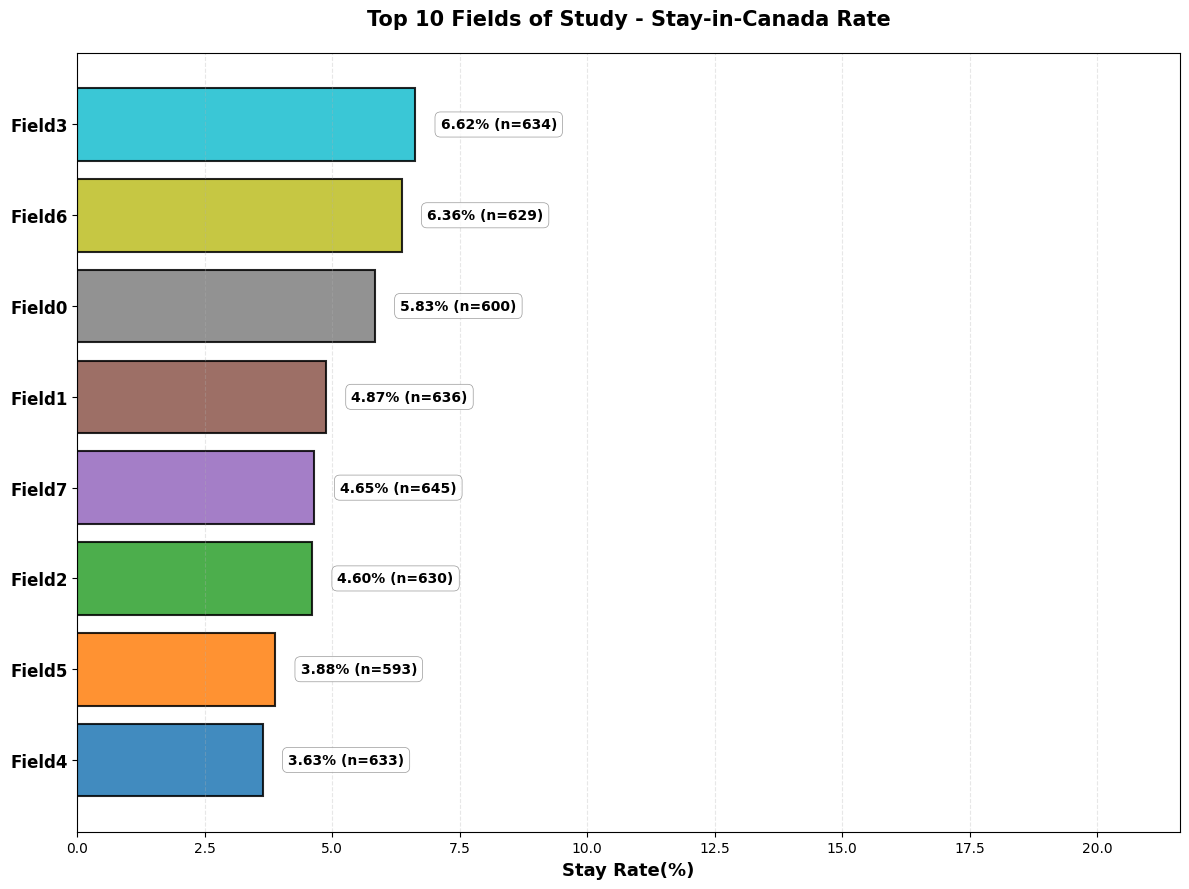


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

Field ID    |Total Students |Stay Rate   |Stayed Count
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
4           |633            |3.63        %|23          
5           |593            |3.88        %|23          
2           |630            |4.60        %|29          
7           |645            |4.65        %|30       

In [22]:
top_fields=data["field_of_study"].value_counts().head(10).index
subset=data[data["field_of_study"].isin(top_fields)]
field_stats=subset.groupby("field_of_study")["stay_in_canada"].agg(['count','mean']).reset_index()
field_stats.columns=['field_id','total','rate']
field_stats=field_stats.sort_values('rate',ascending=True)
fig,ax=plt.subplots(figsize=(12,9))
colors=plt.cm.tab10(np.linspace(0,1,len(field_stats)))
bars=ax.barh(range(len(field_stats)),field_stats['rate'].values * 100,color=colors,alpha=0.85,edgecolor='black',linewidth=1.5)
ax.set_yticks(range(len(field_stats)))
ax.set_yticklabels([f"Field{int(f)}" for f in field_stats['field_id'].values],fontsize=12,fontweight='bold')
ax.set_xlabel('Stay Rate(%)',fontsize=13,fontweight='bold')
ax.set_title('Top 10 Fields of Study - Stay-in-Canada Rate',fontsize=15,fontweight='bold',pad=20)
ax.set_xlim(0,max(field_stats['rate'].values * 100)+15)
ax.grid(axis='x',alpha=0.3,linestyle='--')
for i,(rate,total) in enumerate(zip(field_stats['rate'].values * 100,field_stats['total'].values)):
    ax.text(rate + 0.5,i,f'{rate:.2f}% (n={int(total)})',va='center',fontsize=10,fontweight='bold',bbox=dict(boxstyle='round,pad=0.4',facecolor='white',alpha=0.8,edgecolor='gray',linewidth=0.5))
plt.tight_layout()
plt.show()
print("\n"+"___"*80)
print("___"*80)
print(f"\n{'Field ID':<12}|{'Total Students':<15}|{'Stay Rate':<12}|{'Stayed Count':<12}")
print("___"*80)
for idx,row in field_stats.iterrows():
    stayed_count=int(row['total'] * row['rate'])
    print(f"{int(row['field_id']):<12}|{int(row['total']):<15}|{row['rate']*100:<12.2f}%|{stayed_count:<12}")
print(f"\nTop 3 Fields with Highest Stay Rate:")
top3=field_stats.nlargest(3,'rate')
for rank,(idx,row) in enumerate(top3.iterrows(),1):
    stayed_count=int(row['total'] * row['rate'])
    print(f"{rank}. Field{int(row['field_id'])}:{row['rate']*100:.2f}% ({stayed_count}/{int(row['total'])}students)")
print(f"\nBottom 3 Fields with Lowest Stay Rate:")
bottom3=field_stats.nsmallest(3,'rate')
for rank,(idx,row) in enumerate(bottom3.iterrows(),1):
    stayed_count=int(row['total'] * row['rate'])
    print(f"{rank}. Field{int(row['field_id'])}:{row['rate']*100:.2f}%({stayed_count}/{int(row['total'])}students)")
print("\n"+"___"*80)

In [23]:
print("\n (4/5)Visa and Post-Graduation Employment Analysis")


 (4/5)Visa and Post-Graduation Employment Analysis


/tmp/ipython-input-2170329998.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




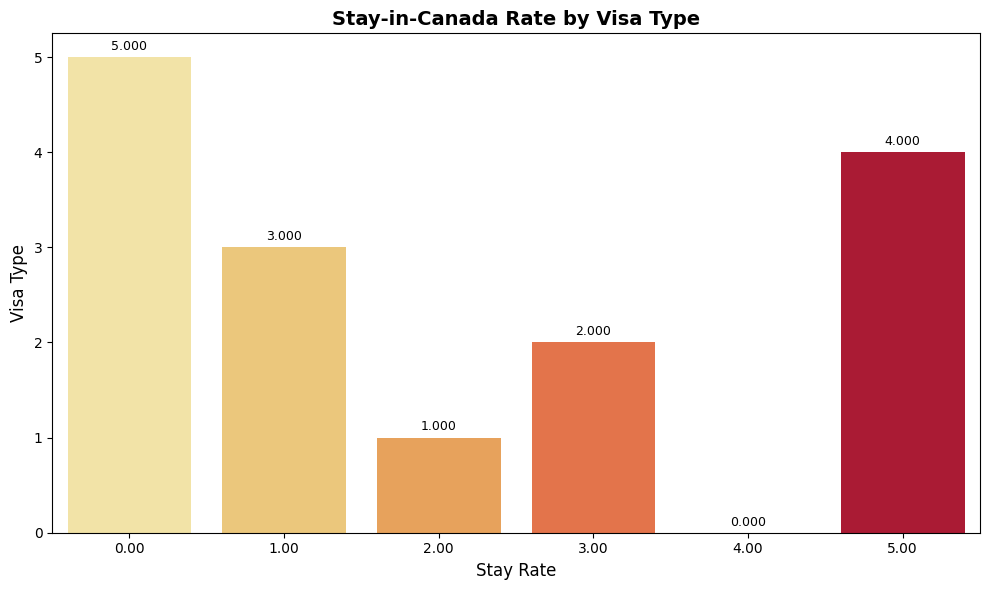

In [24]:
visa=data.groupby("visa_status")["stay_in_canada"].mean().reset_index()
visa=visa.sort_values(by="stay_in_canada",ascending=False)
plt.figure(figsize=(10,6))
bar_plot=sns.barplot(data=visa,x="stay_in_canada",y="visa_status",palette="YlOrRd")
plt.title("Stay-in-Canada Rate by Visa Type",fontsize=14, fontweight='bold')
plt.xlabel("Stay Rate",fontsize=12)
plt.ylabel("Visa Type",fontsize=12)
xticks=bar_plot.get_xticks()
tick_interval=max(1,len(xticks)//6)
xticks_filtered=xticks[::tick_interval]
bar_plot.set_xticks(xticks_filtered)
bar_plot.set_xticklabels([f"{x:.2f}"for x in xticks_filtered],fontsize=10)
for container in bar_plot.containers:
    bar_plot.bar_label(container,fmt="%.3f",label_type="edge",fontsize=9,padding=3)
plt.tight_layout()
plt.show()

In [28]:
post_visa=data.groupby("post_graduation_visa")["stay_in_canada"].agg(['count','sum','mean']).reset_index()
post_visa.columns=['visa','total','stayed','rate']
post_visa['not_stayed']=post_visa['total']-post_visa['stayed']
chi2,chi_pvalue, _, _ =chi2_contingency(pd.crosstab(data['post_graduation_visa'],data['stay_in_canada']))
fig,ax=plt.subplots(figsize=(16,10))
colors=plt.cm.Set3(np.linspace(0,1,len(post_visa)))
x_pos=np.arange(len(post_visa))
for i,(idx,row) in enumerate(post_visa.iterrows()):
    stay_rate=row['rate'] * 100
    total=row['total']
    bubble=ax.scatter(i,stay_rate,s=total*3,alpha=0.6,color=colors[i],edgecolors='black',linewidth=2.5,zorder=3)
    ax.text(i,stay_rate,f"{stay_rate:.1f}%",ha='center',va='center',fontsize=13,fontweight='bold',bbox=dict(boxstyle='round,pad=0.6',facecolor='white',alpha=0.95,edgecolor='black',linewidth=1.5))
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Visa Type{int(v)}"for v in post_visa['visa'].values],fontsize=13,fontweight='bold')
ax.set_ylabel('Stay Rate(%)',fontsize=14,fontweight='bold')
ax.set_ylim(-2,12)
ax.set_xlim(-0.8,len(post_visa)-0.2)
ax.grid(axis='y',alpha=0.3,linestyle='--',linewidth=1)
ax.text(-0.7,11,'Bubble Size=Total Student Count',fontsize=11,style='italic',fontweight='bold',
bbox=dict(boxstyle='round,pad=0.7',facecolor='lightyellow',alpha=0.8,edgecolor='black',linewidth=1))
for i,(idx,row) in enumerate(post_visa.iterrows()):
    stay_count=int(row['stayed'])
    not_stay=int(row['not_stayed'])
    total=int(row['total'])
    y_offset=9.5 if i %2==0 else 6.8
    ax.text(i,y_offset,f"n={total}\nStayed:{stay_count}\nLeft:{not_stay}",ha='center',fontsize=9,fontweight='bold',bbox=dict(boxstyle='round,pad=0.6',facecolor=colors[i],alpha=0.7,edgecolor='black',linewidth=1.5))
sig_text='Statistically Significant' if chi_pvalue <0.05 else 'Not Significant'
ax.text(0.5,-0.12,f'Chi-Square Test:p-value={chi_pvalue:.4f}|{sig_text}',transform=ax.transAxes,ha='center',fontsize=12,fontweight='bold',bbox=dict(boxstyle='round,pad=0.8',facecolor='lightcyan',alpha=0.85,edgecolor='black',linewidth=2))
ax.set_title('Post-Graduation Visa Status Impact on Stay Decision\n(Bubble Size Represents Total Student Count)',fontsize=15,fontweight='bold',pad=25)
plt.tight_layout()
plt.show()
print("\n"+"___"*80)
print("POST-GRADUATION VISA ANALYSIS --- BUBBLE CHART INTERPRETATION")
print("___"*80)
print("\nVisualization Guide:")
print("•Bubble Size=Total number of students for this visa type")
print("•Bubble Center=Stay Rate(%) for this visa type")
print("•Bubble Color=Different visa types for easy identification")
print("\nDetailed Data Summary:")
for idx, row in post_visa.iterrows():
    print(f"\nVisa Type {int(row['visa'])}:")
    print(f"Total Students:{int(row['total'])}")
    print(f"Stayed in Canada:{int(row['stayed'])}")
    print(f"Left Canada:{int(row['not_stayed'])}")
    print(f"Stay Rate:{row['rate']*100:.2f}%")
print(f"\nChi-Square Test Results:")
print(f"Test Statistic:{chi2:.4f}")
print(f"P-value:{chi_pvalue:.6f}")
print(f"Conclusion:{'STATISTICALLY SIGNIFICANT' if chi_pvalue < 0.05 else 'NOT STATISTICALLY SIGNIFICANT'}")
print(f"Interpretation: Post-graduation visa status and stay decision are {'SIGNIFICANTLY' if chi_pvalue <0.05 else 'NOT SIGNIFICANTLY'} related")
print("\n"+"___"*80)


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
POST-GRADUATION VISA ANALYSIS --- BUBBLE CHART INTERPRETATION
________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

Visualization Guide:
•Bubble Size=Total number of students for this visa type
•Bubble Center=Stay Rate(%) for this visa type
•Bubble Color=Different visa types for easy identification

Detailed Data Summary:

Visa Type 0:
Total Students:1029
Stayed in Canada:56
Left Canada:973
Stay Rate:5.44%

Visa Type 1:
Total Students:1012
Stayed in Canada:56
Left Canada:956
Stay Rate:5.53%

Visa Type 2:
Total Students:950
Stayed in Canada:49
Left Canada:901
Stay 

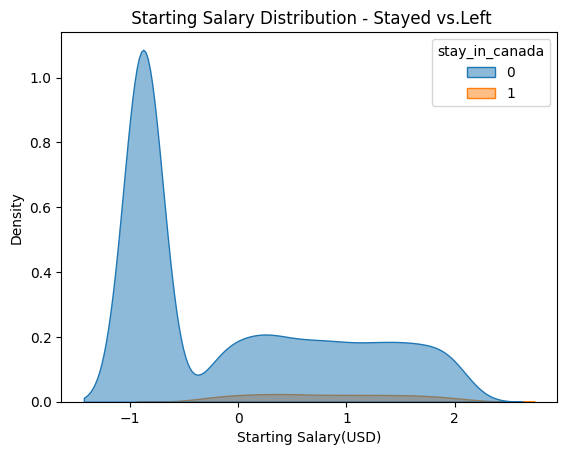

In [25]:
sns.kdeplot(data=data,x="starting_salary_usd",hue="stay_in_canada",fill=True,alpha=0.5)
plt.title(" Starting Salary Distribution - Stayed vs.Left")
plt.xlabel("Starting Salary(USD)")
plt.show()

In [26]:
print("\n (5/5) Comprehensive Dashboard and Insights")


 (5/5) Comprehensive Dashboard and Insights


In [27]:
warnings.filterwarnings('ignore')
matplotlib.use('Agg')
plt.rcParams['figure.dpi']=80
plt.rcParams['savefig.dpi']=80
plt.rcParams['font.size']=10
print("\n"+"___"*100)
print("CRITICAL DISCOVERY METRICS")
print("___"* 100)
global_stay_rate=(data['stay_in_canada']==1).mean()*100
stem_stay_rate=data[data['stem_flag']==1]['stay_in_canada'].mean()*100
non_stem_stay_rate=data[data['stem_flag']==0]['stay_in_canada'].mean()*100
scholarship_with=data[data['scholarship_flag']==1]['stay_in_canada'].mean()*100
scholarship_without=data[data['scholarship_flag']==0]['stay_in_canada'].mean()*100
scholarship_impact=scholarship_with - scholarship_without
gpa_stayed=data[data['stay_in_canada']==1]['gpa_or_score'].dropna().mean()
gpa_left=data[data['stay_in_canada']==0]['gpa_or_score'].dropna().mean()
salary_stayed=pd.to_numeric(data[data['stay_in_canada']==1]['starting_salary_usd'],errors='coerce').dropna().mean()
salary_left=pd.to_numeric(data[data['stay_in_canada']==0]['starting_salary_usd'],errors='coerce').dropna().mean()
print(f"\n Global Stay Rate:{global_stay_rate:.2f}%")
print(f"STEM Stay Rate:{stem_stay_rate:.2f}%")
print(f"Non-STEM Stay Rate:{non_stem_stay_rate:.2f}%")
print(f"STEM vs Non-STEM Gap:{stem_stay_rate - non_stem_stay_rate:.2f}percentage points")
print(f"Scholarship with Support:{scholarship_with:.2f}%")
print(f"Scholarship without Support:{scholarship_without:.2f}%")
print(f"Scholarship Holder Advantage:{scholarship_impact:.2f}percentage points")
print(f"GPA Difference (Stayed vs Left):{gpa_stayed - gpa_left:.3f}points")
print(f"Salary Difference (Stayed vs Left):${salary_stayed - salary_left:,.2f}USD")
print("\n"+"___"*100)
print("COMPREHENSIVE VISUALIZATION DASHBOARD")
print("___"*100+"\n")
fig=plt.figure(figsize=(16,10),dpi=80)
stay_counts=data['stay_in_canada'].value_counts().sort_index()
labels=['Left Canada','Stayed in Canada']
ax1=plt.subplot(2,3,1)
colors_pie=['#e74c3c','#2ecc71']
try:
    ax1.pie(stay_counts.values,labels=labels,autopct=lambda pct:f'{pct:.1f}%',
           colors=colors_pie,startangle=90,textprops={'fontsize':10,'fontweight':'bold'})
except:
    ax1.pie(stay_counts.values,labels=labels,colors=colors_pie,startangle=90)
ax1.set_title('Overall Distribution\n(All Students)',fontsize=11,fontweight='bold',pad=10)
ax2=plt.subplot(2,3,2)
stem_data=[non_stem_stay_rate,stem_stay_rate]
bars=ax2.bar(['Non-STEM','STEM'],stem_data,color=['#3498db','#e67e22'],alpha=0.8,edgecolor='black',linewidth=1.5)
ax2.set_ylabel('Stay Rate (%)',fontsize=10,fontweight='bold')
ax2.set_title('STEM Advantage\n(Highest Factor)',fontsize=11,fontweight='bold',pad=10)
ax2.set_ylim(0,max(stem_data)+2)
for bar,val in zip(bars,stem_data):
    ax2.text(bar.get_x()+bar.get_width()/2,val+0.15,f'{val:.2f}%',ha='center', fontsize=9, fontweight='bold')
ax2.grid(axis='y',alpha=0.2,linestyle='--')
ax3=plt.subplot(2,3,3)
gpa_comparison=[gpa_left,gpa_stayed]
bars=ax3.bar(['Left','Stayed'],gpa_comparison,color=['#e74c3c','#2ecc71'],alpha=0.8,edgecolor='black',linewidth=1.5)
ax3.set_ylabel('Average GPA',fontsize=10,fontweight='bold')
ax3.set_title('Academic Performance\n(GPA Effect)',fontsize=11,fontweight='bold',pad=10)
for bar,val in zip(bars,gpa_comparison):
    ax3.text(bar.get_x()+bar.get_width()/2,val+0.03,f'{val:.2f}',ha='center',fontsize=9,fontweight='bold')
ax3.grid(axis='y',alpha=0.2,linestyle='--')
ax4=plt.subplot(2,3,4)
scholarship_rates=[scholarship_without,scholarship_with]
bars=ax4.bar(['No Scholarship','Has Scholarship'],scholarship_rates,color=['#95a5a6','#27ae60'],alpha=0.8,edgecolor='black',linewidth=1.5)
ax4.set_ylabel('Stay Rate(%)',fontsize=10,fontweight='bold')
ax4.set_title('Scholarship Impact\n(Financial Support)',fontsize=11,fontweight='bold',pad=10)
ax4.set_ylim(0,max(scholarship_rates)+2)
for bar, val in zip(bars,scholarship_rates):
    ax4.text(bar.get_x()+bar.get_width()/2,val+0.15,f'{val:.2f}%',ha='center',fontsize=9,fontweight='bold')
ax4.grid(axis='y',alpha=0.2,linestyle='--')
ax5=plt.subplot(2,3,5)
salary_comparison=[salary_left,salary_stayed]
bars=ax5.bar(['Left','Stayed'],salary_comparison,color=['#e74c3c','#2ecc71'],alpha=0.8,edgecolor='black',linewidth=1.5)
ax5.set_ylabel('Avg Salary (USD)',fontsize=10,fontweight='bold')
ax5.set_title('Employment Outcome\n(Salary Proxy)',fontsize=11,fontweight='bold',pad=10)
for bar,val in zip(bars,salary_comparison):
    if not np.isnan(val) and val>0:
        ax5.text(bar.get_x()+bar.get_width()/2,val+1500,f'${val/1000:.0f}K',ha='center',fontsize=8,fontweight='bold')
ax5.grid(axis='y',alpha=0.2,linestyle='--')
ax6=plt.subplot(2,3,6)
try:
    top_5_countries=data.groupby('origin_country')['stay_in_canada'].agg(['count','mean']).sort_values('mean',ascending=False).head(5)
    if len(top_5_countries)>0:
        country_names=[f'C{int(c)}' for c in top_5_countries.index]
        country_rates=top_5_countries['mean'].values*100
        bars=ax6.barh(country_names,country_rates,color=plt.cm.Set3(np.linspace(0,1,len(country_rates))),alpha=0.8, edgecolor='black', linewidth=1.5)
        ax6.set_xlabel('Stay Rate(%)',fontsize=10,fontweight='bold')
        ax6.set_title('Top 5 Countries\n(Geographic)',fontsize=11,fontweight='bold',pad=10)
        for bar,val in zip(bars,country_rates):
            ax6.text(val+0.2,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',fontsize=8,fontweight='bold')
        ax6.grid(axis='x',alpha=0.2,linestyle='--')
except Exception as e:
    ax6.text(0.5,0.5,'Data Processing\nError',ha='center',va='center',fontsize=10)
    ax6.set_title('Top 5 Countries',fontsize=11,fontweight='bold',pad=10)
plt.suptitle('Comprehensive Student Stay in the Canada Analysis Dashboard',fontsize=13,fontweight='bold',y=1)
plt.subplots_adjust(top=0.94,bottom=0.08,left=0.08,right=0.95,hspace=0.4,wspace=0.3)
try:
    plt.savefig('dashboard.png',dpi=80,bbox_inches='tight',facecolor='white')
    print(" Dashboard saved successfully\n")
except:
    print(" Could not save dashboard\n")
display(fig)
plt.show()
plt.close()
print("\n"+"___"*100)
print("STRATEGIC INSIGHTS TABLE")
print("___"*100)
insights_table=pd.DataFrame({"Dimension":["Geographic Origin","Educational Background","Field of Study","Financial Factors","Visa and Employment"],"Key Finding":[f"Regional variance:{top_5_countries['mean'].min()*100:.1f}% -{top_5_countries['mean'].max()*100:.1f}%",f"GPA difference: {gpa_stayed - gpa_left:.3f} points (Stayed higher)",f"STEM advantage:{stem_stay_rate - non_stem_stay_rate:.2f}pp over Non-STEM",f"Scholarship impact:{scholarship_impact:.2f}pp difference",f"Employment drives retention decisions"],"Recommendation": ["Target high-performing geographic regions","Recruit high-achievement students","Expand STEM program support","Increase scholarship allocation","Strengthen employer partnerships"]})
print("\n")
print(insights_table.to_string(index=False))
print("\n"+"___"*100)


____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
CRITICAL DISCOVERY METRICS
____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

 Global Stay Rate:5.06%
STEM Stay Rate:5.62%
Non-STEM Stay Rate:4.87%
STEM vs Non-STEM Gap:0.75percentage points
Scholarship with Support:4.70%
Scholarship without Support:5.45%
Scholarship Holder Advantage:-0.75percentage points
GPA Difference (Stayed vs Left):0.063points
Salary Difference (Stayed vs Left):$0.88USD

__________________________________________________


____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
STRATEGIC INSIGHTS TABLE
____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________


             Dimension                                  Key Finding                            Recommendation
     Geographic Origin                 Regional variance:5.3% -7.0% Target high-performing geographic regions
Educational Background GPA difference: 0.063 points (Stayed higher)         Recruit high-achievement students
        Field of Study          STEM adv